***
# Flow Control
***


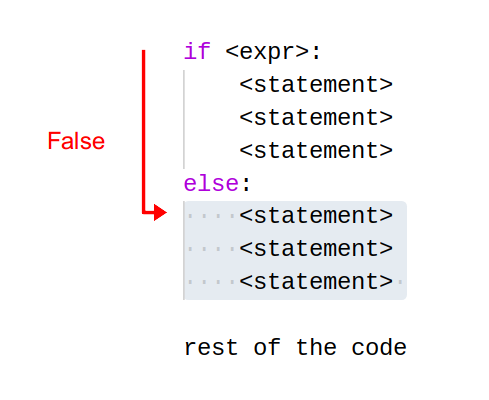

In [1]:
# 單尾檢定：用統計量是否落在拒絕域決定結論
Tstat = 1.344  # 設定檢定統計量，供下一行分支判斷
if Tstat > 1.96:  # 統計量落在右尾拒絕域時走這個分支
    print('reject H0')  # 輸出拒絕 H0 的結論
else:  # 其餘情況視為證據不足
    print('do not reject H0')  # 輸出不拒絕 H0


do not reject H0


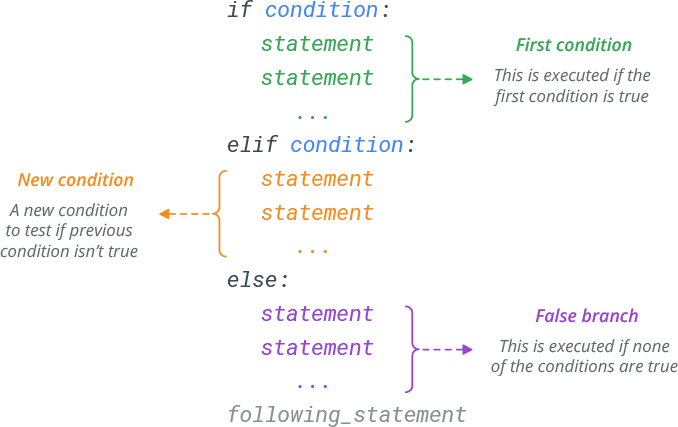

In [2]:
# 雙尾檢定：分別檢查左右尾是否超過臨界值
Ts = 0.88
if (Ts > 1.645):
    print('reject H0')
elif (Ts < -1.645):
    print('reject H0')
else:
    print('do not reject H0')

Ts2 = 0.23
if (-1.645 < Ts2 < 1.645):
    print('reject H0')
else:
    print('do not reject H0')


do not reject H0
reject H0


***
## 巢狀 `if`
***
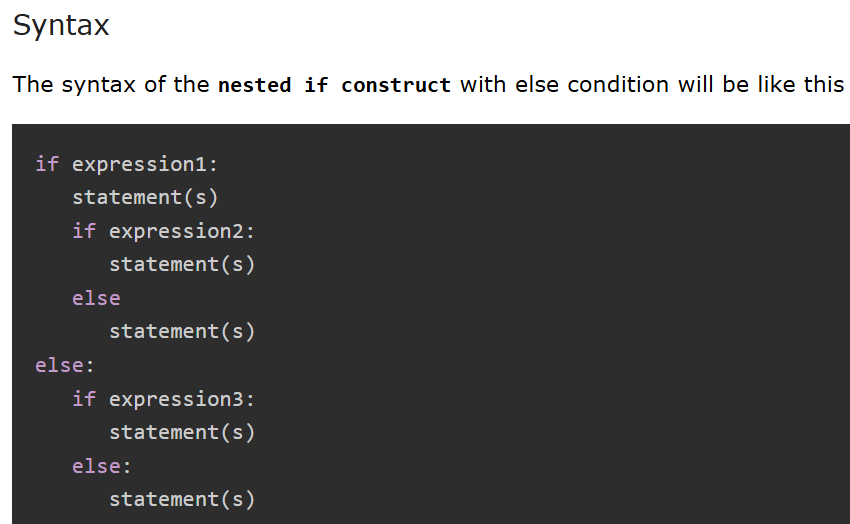  


***
## 連續性的條件判斷
***
若 `left limit = right limit`，則極限存在；
再檢查該極限是否等於函數值 `f(a)`，才能判斷函數在該點是否連續。
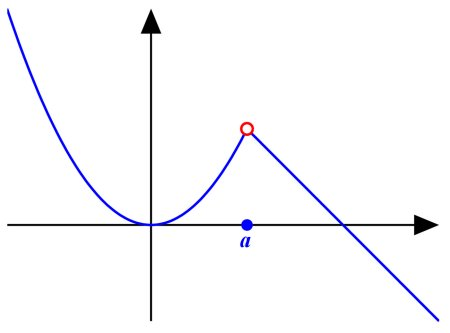


In [3]:
vL = 8
vR = 8
vT = 5
if (vL != vR):  # 左右極限不一致就無法談連續
    print('left limit != right limit. => Then limit not exist')
else:
    print('left limit = right limit. => Then limit exist')
    if (vL == vT) & (vR == vT):  # 極限存在且等於函數值才連續
        print('limit = defined value. => It conti at point')
    else:
        print('It is removable discontinuities')

left limit = right limit. => Then limit exist
It is removable discontinuities


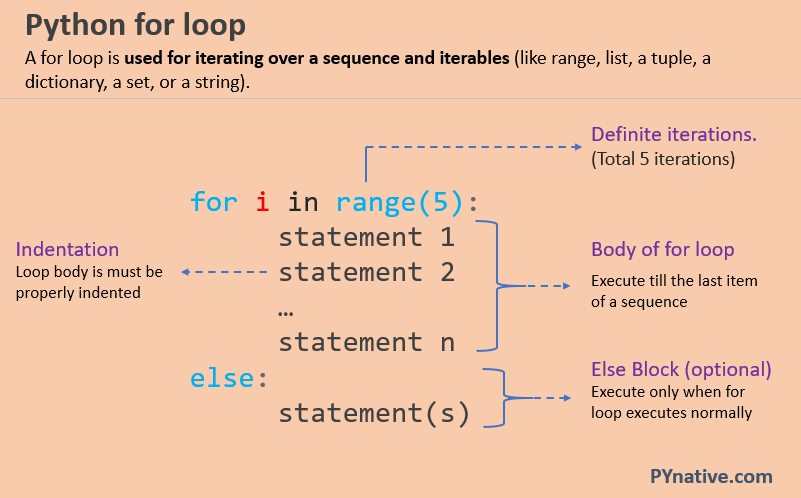

In [4]:
import math
for x in range(10):  # Total iterations
    theta = math.pi * x / 2     # 把整數 x 轉成角度 x*pi/2
    val = math.sin(theta)       # 計算該角度的 sine 值
    print(f'sin at {x}pi/2 = {val:.0f}')  # `:.0f` 顯示為整數，不印小數位


sin at 0pi/2 = 0
sin at 1pi/2 = 1
sin at 2pi/2 = 0
sin at 3pi/2 = -1
sin at 4pi/2 = -0
sin at 5pi/2 = 1
sin at 6pi/2 = 0
sin at 7pi/2 = -1
sin at 8pi/2 = -0
sin at 9pi/2 = 1


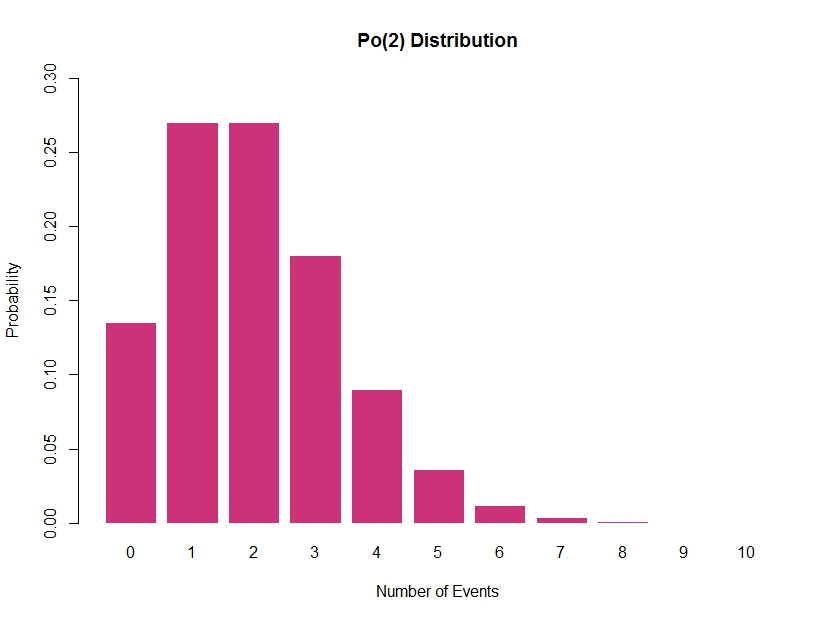

In [5]:
# 用指定 x 值查 Poisson(r=2) 的機率質量
import scipy.stats as scs
r = 2  # 參數 (lambda)
for x in [0,1,2,4,5]:
    val = scs.poisson.pmf(x,r)  # `poisson.pmf()`：Poisson 分配的 PMF
    print(f'P(X = {x}) = {val:.5f}')


P(X = 0) = 0.13534
P(X = 1) = 0.27067
P(X = 2) = 0.27067
P(X = 4) = 0.09022
P(X = 5) = 0.03609


In [6]:
Score_Book = {'Hardy':60,  # name, score
              'Riemann':40,
              'Lehmann':20,
              'Linderberg':87,
              'Cauchy':66}
for name,score in Score_Book.items():  # `for name,score in ...`
    print(f'{name} get {score} on Python')


Hardy get 60 on Python
Riemann get 40 on Python
Lehmann get 20 on Python
Linderberg get 87 on Python
Cauchy get 66 on Python


In [7]:
# 同一份成績資料直接分流成及格/不及格
for name,score in Score_Book.items():
    if score < 60:
        print(f'{name} is failed on Python')
    else:
        print(f'{name} is passed on Python')


Hardy is passed on Python
Riemann is failed on Python
Lehmann is failed on Python
Linderberg is passed on Python
Cauchy is passed on Python


In [8]:
# 把元素名稱與比例對齊後成對輸出
prods = ['Ni','Cr','Mo','Mn','Cu']
vals = [0.08,0.17,0.02,0.012,0.005]
for i,j in zip(prods,vals):  # zip: 逐元素配對，並指派給i, j
    print(f'{i} = {100*j} %')

Ni = 8.0 %
Cr = 17.0 %
Mo = 2.0 %
Mn = 1.2 %
Cu = 0.5 %


In [9]:
# 一次列出 1~4 的全部乘法配對
from itertools import product
for i,j in product(range(1,5),range(1,5)):  # `product(A, B)`：列出兩個 iterable 的 Cartesian product
    print(f'{i} * {j} = {i*j}')


1 * 1 = 1
1 * 2 = 2
1 * 3 = 3
1 * 4 = 4
2 * 1 = 2
2 * 2 = 4
2 * 3 = 6
2 * 4 = 8
3 * 1 = 3
3 * 2 = 6
3 * 3 = 9
3 * 4 = 12
4 * 1 = 4
4 * 2 = 8
4 * 3 = 12
4 * 4 = 16


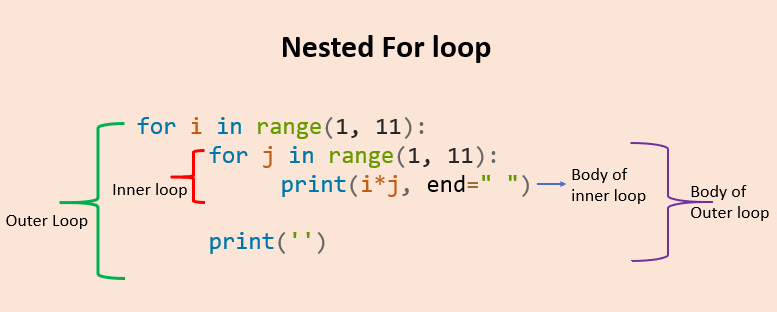

In [10]:
n = 11  # 用奇數長度字串逐列堆出置中圖樣
for i in range(3,n,2):
    for j in range(1,i+1,2):
        print(('1'*j).center(n," "))  # `'1' * j`：重複字串；`str.center(width, fill)`：置中補齊


     1     
    111    
     1     
    111    
   11111   
     1     
    111    
   11111   
  1111111  
     1     
    111    
   11111   
  1111111  
 111111111 


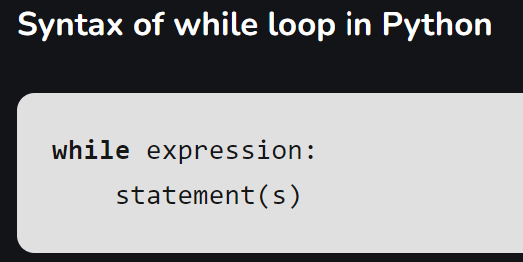

In [11]:
# 先用模擬估雙尾機率，再用積分做基準對照
import numpy as np
from scipy.integrate import quad
import scipy.stats as scs
keep = []
runs = 10000
count = 0
while len(keep) < runs:  # `while`：條件為真就持續迴圈
    val = float(np.random.standard_normal(1)[0])  # 每次抽一個標準常態樣本
    if abs(val) > 1.96:  # 只收下落在兩側尾端的樣本
        keep.append(val)  # 把合格樣本存入 keep
    count += 1  # 累加總抽樣次數作為分母
# 用數值積分計算理論雙尾機率作對照
intv1 = quad(lambda x:scs.norm.pdf(x),1.96,np.inf)[0]
intv2 = quad(lambda x:scs.norm.pdf(x),-np.inf,-1.96)[0]
display(f'prob = {len(keep) / count:.3f} by monte carlo',  # 同時顯示 MC 估計與理論值
        f'prob = {intv1 + intv2:.3f} by numerical integration')


'prob = 0.050 by monte carlo'

'prob = 0.050 by numerical integration'

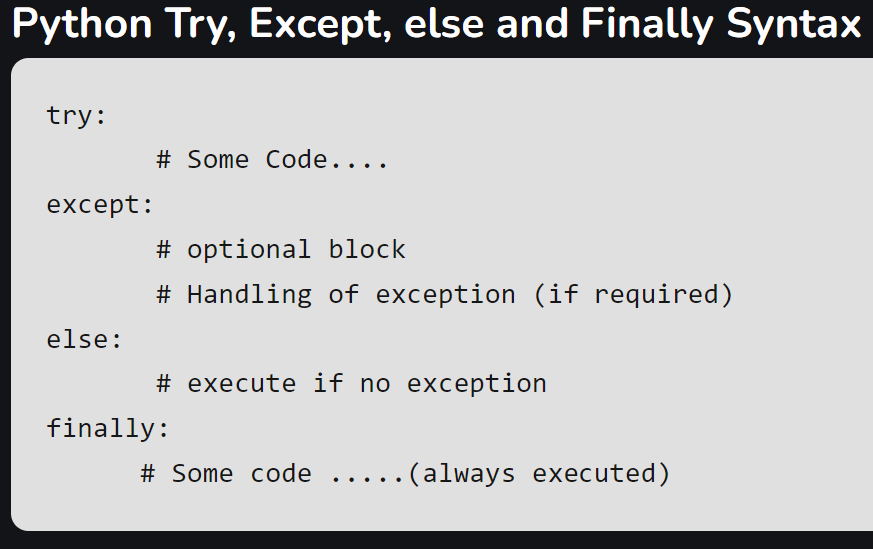

In [12]:
a = 9  # 示範例外處理流程與收尾邏輯
for b in [-1,0,1]:
    try:
        print(a / b)
    except Exception as e:  # `except Exception as e`：接住例外並綁到 `e`
        print(e)
    else:
        print('ok go')
    finally:  # `finally`：不論有無例外都會執行
        print('pass anyway \n')


-9.0
ok go
pass anyway 

division by zero
pass anyway 

9.0
ok go
pass anyway 



***
## `break` 與 `continue`
***
- `break`：直接結束整個迴圈
- `continue`：跳過本圈剩餘語句，進入下一圈


In [13]:
count = 0  # 計算跑到第一個母音前共檢查幾個字母
for alphabet in 'pythagorean':
    count += 1
    if alphabet in list('aeiou'):  # 遇到母音就停止，不再往後掃
        break
    print(alphabet)
print('\n迴圈結束')
print(f'迴圈執行了 {count} 次')


p
y
t
h

迴圈結束
迴圈執行了 5 次


In [14]:
count = 0  # 計算整個字串總共檢查幾個字母
for alphabet in 'pythagorean':
    count += 1
    if alphabet in list('aeiou'):  # 遇到母音只跳過本次輸出，迴圈仍繼續
        continue
    print(alphabet)
print('\n迴圈結束')
print(f'迴圈執行了 {count} 次')


p
y
t
h
g
r
n

迴圈結束
迴圈執行了 11 次


***
## Linear Congruential Generator（LCG）
***
$X_{i+1} = a X_i + c \hbox{ (mod m)}$

下面用幾組 modulo-9 的參數比較循環長度，觀察 seed 與參數如何影響週期。


In [15]:
def lcg(X0,a,c,m,size):  # LCG：用遞推式生成有限長度序列
    # 序列第一項固定為 seed
    Xs = [X0]
    # 從第二項開始套用遞推直到 size
    for i in range(1,size):
        Xs.append((a * Xs[i - 1] + c) % m)  # 把新值接到序列尾端
    return Xs  # 回傳完整序列
# 設定本次 LCG 參數
seed = 1
a,c,m = 2,0,9
size = 12
# 這組參數形成週期長度 6
# 產生序列供觀察
random_seq = lcg(seed,a,c,m,size)  # 呼叫 lcg 產生序列供觀察
random_seq


[1, 2, 4, 8, 7, 5, 1, 2, 4, 8, 7, 5]

In [16]:
# LCG 參數
seed = 3
a,c,m = 2,0,9
size = 4
# 改 seed 後週期縮成 2
# 產生序列供觀察
random_seq = lcg(seed,a,c,m,size)
random_seq


[3, 6, 3, 6]

In [17]:
# LCG 參數
seed = 0
a,c,m = 4,1,9
size = 18
# 另一組參數可達週期長度 9
# 產生序列供觀察
random_seq = lcg(seed,a,c,m,size)
random_seq


[0, 1, 5, 3, 4, 8, 6, 7, 2, 0, 1, 5, 3, 4, 8, 6, 7, 2]

***
## Root Finding Algorithms
***
- Bisection method
- Newton method
- Secant method
- Fixed-point iteration
- Steffensen method


In [18]:
def bisec(f,a,b,tol = 1e-6,max_iter = 100):  # 同題並排五種 root-finding 以比較收斂行為
    if f(a)*f(b) >= 0:  # 先驗證端點變號，否則二分法不成立
        raise ValueError("Must change sign on [a, b].")  # 不符合變號條件就直接中止
    for i in range(max_iter):
        c = (a + b) / 2
        fc = f(c)
        if abs(fc) < tol or (b - a) / 2 < tol:  # 函數值夠小或區間夠短就視為收斂
            return c  # `return`：回傳結果並結束函式
        # 保留仍含根的一半區間
        if f(a) * fc < 0:
            b = c
        else:
            a = c
    raise RuntimeError("Maximum number of iterations reached without finding a root.")

def newton(f,g,x0,tol = 1e-6,max_iter = 100):  # 牛頓法：用切線更新下一個根估計值
    xc = x0
    for k in range(max_iter):
        if abs(g(xc)) < tol:
            print("Division by zero.")
            return None  # `return`：回傳結果並結束函式
        xn = xc - (f(xc) / g(xc))
        diff = abs(xn - xc)
        if diff < tol:
            return xn  # `return`：回傳結果並結束函式
        xc = xn
    print("Reached maximum iterations.")
    return xc  # `return`：回傳結果並結束函式

def secant(f,x0,x1,tol = 1e-6,max_iter = 100):  # 割線法以兩點斜率近似導數
    for i in range(max_iter):
        fx0 = f(x0)
        fx1 = f(x1)
        if abs(fx1 - fx0) < tol:
            print("Mathematical error: Division by zero.")
            return None  # `return`：回傳結果並結束函式
        xn = x1 - fx1 * (x1 - x0) / (fx1 - fx0)
        if abs(xn - x1) < tol:
            return xn  # `return`：回傳結果並結束函式

        # Update points for the next iteration
        x0, x1 = x1, xn
    print("Reached maximum iterations.")
    return x1  # `return`：回傳結果並結束函式

def fixed_pt(f,x0,tol = 1e-6,max_iter = 100):  # 固定點法：反覆套 f(x) 直到相鄰差小於容忍值
    xc = x0
    for k in range(max_iter):
        xn = f(xc)
        diff = abs(xn - xc)
        if diff < tol:
            return xn  # `return`：回傳結果並結束函式
        xc = xn
    print("Reached maximum iterations.")
    return xc  # `return`：回傳結果並結束函式

def steff(f,x0,tol = 1e-6,max_iter = 100):  # Steffensen 在固定點框架下加速
    xc = x0
    for k in range(max_iter):
        fx = f(xc)
        xn = xc - (fx**2 / (f(xc+fx) - fx))
        diff = abs(xn - xc)
        if diff < tol:
            return xn  # `return`：回傳結果並結束函式
        xc = xn
    print("Reached maximum iterations.")
    return xc  # `return`：回傳結果並結束函式


In [19]:
f1 = lambda x: x - np.cos(x)
f2 = lambda x: 1 + np.sin(x)
f3 = lambda x: np.cos(x)

display(bisec(f1,0,np.pi),  # 同場比較各方法求得的近似根
        newton(f1,f2,0.5),
        secant(f1,0.5,1),
        fixed_pt(f3,0.5),
        steff(f1,0.5))


0.7390851262506977

np.float64(0.7390851332151607)

np.float64(0.7390851332151606)

np.float64(0.7390848229131414)

np.float64(0.7390851332151607)

***
## 大數法則（Law of Large Numbers）
***
For $i = 1,\cdots,n$  
  
$\displaystyle P(X_i = j) = \frac{1}{6},\hbox{  }j=1,\ldots,6$

$\displaystyle \frac{X_1 + \cdots + X_n}{n}\rightarrow \mu = 3.5$


In [20]:
import matplotlib.pyplot as plt
plt.style.available  # `plt.style.available`：列出可用繪圖風格


['Solarize_Light2',
 '_classic_test_patch',
 '_mpl-gallery',
 '_mpl-gallery-nogrid',
 'bmh',
 'classic',
 'dark_background',
 'fast',
 'fivethirtyeight',
 'ggplot',
 'grayscale',
 'petroff10',
 'seaborn-v0_8',
 'seaborn-v0_8-bright',
 'seaborn-v0_8-colorblind',
 'seaborn-v0_8-dark',
 'seaborn-v0_8-dark-palette',
 'seaborn-v0_8-darkgrid',
 'seaborn-v0_8-deep',
 'seaborn-v0_8-muted',
 'seaborn-v0_8-notebook',
 'seaborn-v0_8-paper',
 'seaborn-v0_8-pastel',
 'seaborn-v0_8-poster',
 'seaborn-v0_8-talk',
 'seaborn-v0_8-ticks',
 'seaborn-v0_8-white',
 'seaborn-v0_8-whitegrid',
 'tableau-colorblind10']

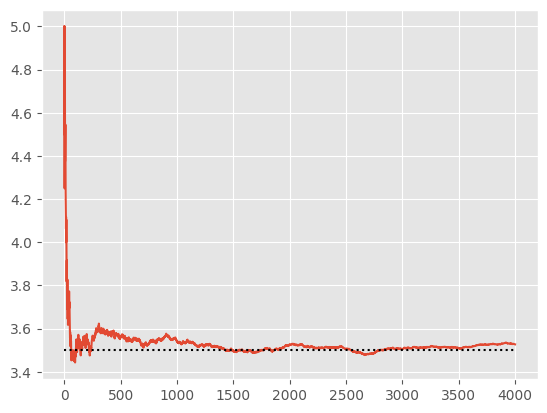

In [21]:
import numpy as np
plt.style.use('ggplot')
csum = 0
runs = 4000
keep = []
for i in range(runs):
    csum += np.random.randint(1, 7, 1)  # 每次擲一顆骰子，累加目前總和
    keep.append(csum / (i + 1))         # 存第 i 次後的累積平均
plt.plot(keep)                          # 畫出累積平均如何靠近 3.5
plt.hlines(y=3.5, xmin=0, xmax=runs,
           colors='black', linestyles='dotted')  # 理論期望值參考線


***
## Monte Carlo 估計 $\pi$
***
Set $X=2U_1 -1$ and $Y = 2U_2 -1$   

Define 
$\displaystyle 
I = \begin{cases}
  1  & X^2+Y^2 \leq 1 \\
  0 & \text{otherwise}
\end{cases}
$  

$\displaystyle E(I) = P(X^2 + Y^2 \leq 1) = \frac{\pi}{4}$


In [22]:
import numpy as np  # 用單位圓命中率反覆估計 pi
n = 10000
runs = 10
for k in range(runs):
    U1 = np.random.uniform(0,1,n)
    U2 = np.random.uniform(0,1,n)
    X = 2 * U1 - 1
    Y = 2 * U2 - 1
    est = 4 * sum((X**2 + Y**2) <= 1) / n  # `(X**2 + Y**2) <= 1` + `sum(bool array)`
    print(f'{k+1} round pi est = {est:.4}')


1 round pi est = 3.173
2 round pi est = 3.15
3 round pi est = 3.126
4 round pi est = 3.145
5 round pi est = 3.123
6 round pi est = 3.142
7 round pi est = 3.166
8 round pi est = 3.117
9 round pi est = 3.153
10 round pi est = 3.176


***
## Inverse Transform Method
***


$\displaystyle 
X = \begin{cases}
  0.2  & X = 0 \\
  0.15 & X = 1 \\
  0.25 & X = 2 \\
  0.4 & X = 3
\end{cases}
$  

(array([24.,  0.,  0., 14.,  0.,  0., 19.,  0.,  0., 43.]),
 array([0. , 0.3, 0.6, 0.9, 1.2, 1.5, 1.8, 2.1, 2.4, 2.7, 3. ]),
 <BarContainer object of 10 artists>)

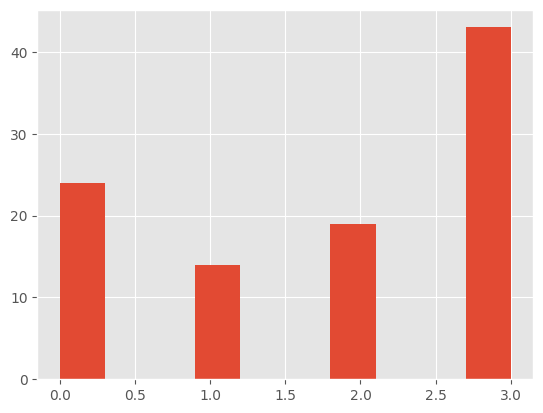

In [23]:
n = 100  # 把均勻樣本映射成離散分布
X = []
for u in np.random.uniform(0,1,n):
    if u < 0.2:
        X += [0]
    elif (0.2 <= u) & (u < 0.35):
        X += [1]
    elif (0.35 <= u) & (u < 0.6):
        X += [2]
    else:
        X += [3]
plt.hist(X)  # `plt.hist()`：畫直方圖


$U \sim U(0,1)$  
$\displaystyle X = \sigma\tan \left( (U-0.5) \pi \right) + \mu$

(array([1.54706191e-06, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 1.54551485e-03]),
 array([-6257.15300004, -5610.76645616, -4964.37991228, -4317.99336839,
        -3671.60682451, -3025.22028062, -2378.83373674, -1732.44719286,
        -1086.06064897,  -439.67410509,   206.71243879]),
 <BarContainer object of 10 artists>)

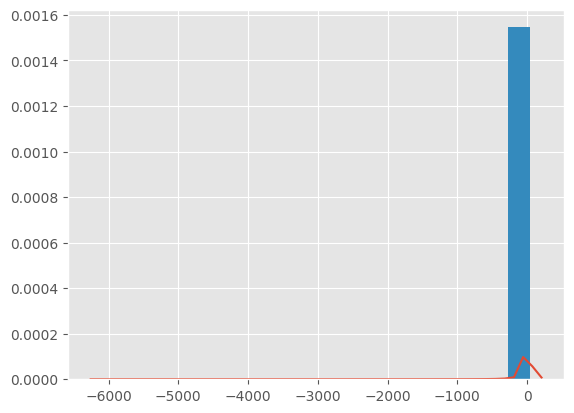

In [24]:
n = 1000  # Cauchy 反 CDF 造樣本並與理論密度疊圖
mu,sigma = 0,1
U = np.random.uniform(0,1,n)
X = sigma * np.tan((U - 0.5) * np.pi) + mu
Xg = np.linspace(min(X),max(X))  # `np.linspace()`：等距產生數值序列
plt.plot(Xg,scs.cauchy.pdf(Xg,mu,sigma))
plt.hist(X,rwidth = 0.5,density = True)


***
## Rejection Sampling
***
若目標密度是 $f(x)$，先找 proposal density $g(x)$ 與常數 $M > 0$，使

$f(x)\leq Mg(x)$。

1. 先抽 $u^{(i)} \sim U(0,1)$ 與 $y^{(i)} \sim g(x)$
2. 若 $u^{(i)}\leq \frac{f(y^{(i)})}{Mg(y^{(i)})}$，就接受 $y^{(i)}$


## 範例
***
$\displaystyle f(x) = \frac{1}{K\cosh(x^2-1)},~\hbox{where }K=\int_{\mathbf{R}}f(x)dx$  
$\displaystyle g(x) \sim N(0,1)$


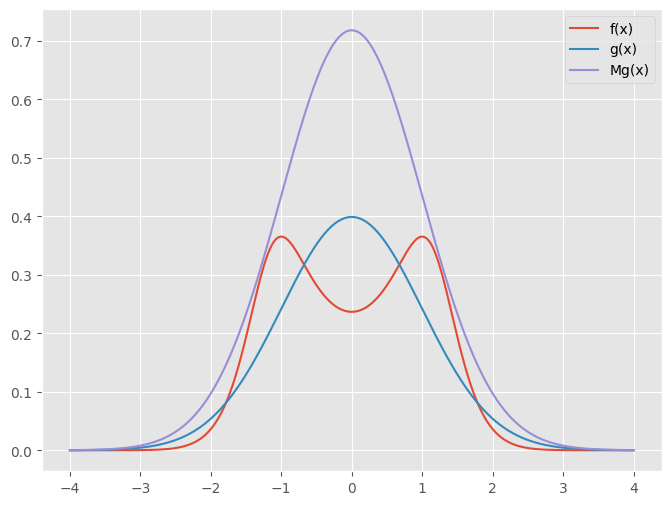

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as scs
from scipy.integrate import quad
import warnings
warnings.filterwarnings('ignore',category = DeprecationWarning)  # `warnings.filterwarnings()`：忽略指定型別的 warning
warnings.filterwarnings('ignore',category = RuntimeWarning)

# 先正規化 target，再檢查 proposal 的包絡關係
normC = quad(lambda x:1 / np.cosh(x**2 - 1),-np.inf,np.inf)[0]

def target(x):  # 定義目標密度 target(x)
    return 1 / (normC * np.cosh(x**2 - 1))
def proposal(x):  # 定義 proposal 密度 g(x)
    return scs.norm.pdf(x)

# rejection sampling 主迴圈
x0 = np.linspace(-4,4,801)
plt.figure(figsize = [8,6])  # `plt.figure(figsize=...)`
plt.plot(x0,target(x0),label = 'f(x)')  # 畫目標密度 f(x)
plt.plot(x0,proposal(x0),label = 'g(x)')  # 畫 proposal g(x)
plt.plot(x0,1.8 * proposal(x0),label = 'Mg(x)')  # 畫 M*g(x) 檢查包絡是否覆蓋
plt.legend()  # `plt.legend()`


0.557


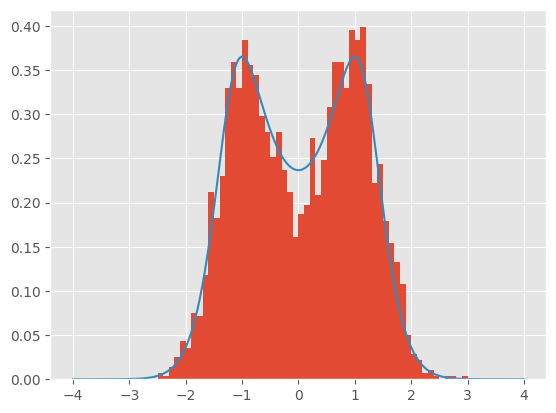

In [26]:
runs = 5000  # Rejection sampling：只接受落在目標密度下的候選值
saver = []
for k in range(runs):
    uk = np.random.uniform()
    yk = np.random.normal()  # `np.random.normal()`：抽一個常態亂數
    if uk <= target(yk) / (1.8 * proposal(yk)):
        saver.append(yk)
plt.hist(saver,density = True,bins = np.arange(-4,4,0.1))
plt.plot(x0,target(x0))
print(len(saver) / runs)


***
## Symmetric Random Walk on $\mathbb{Z}^2$
***
Let $\{X_i,i\in\mathbb{N}\}$ be a sequence of iid random variables satisfying  

$\forall i \in \mathbb{N}~~\forall (x,y)\in \{(0,1),(0,-1),(1,0),(-1,0)\}$  

$P(X_i=(x,y)) = \frac{1}{4}$  

Let $ S_n = \sum_{i=1}^{n}X_i$  

Then $S_n$ is called symmetric random walk on $\mathbb{Z}^2$


path 0 with steps = 375
path 1 with steps = 1401
path 2 with steps = 782
path 3 with steps = 309


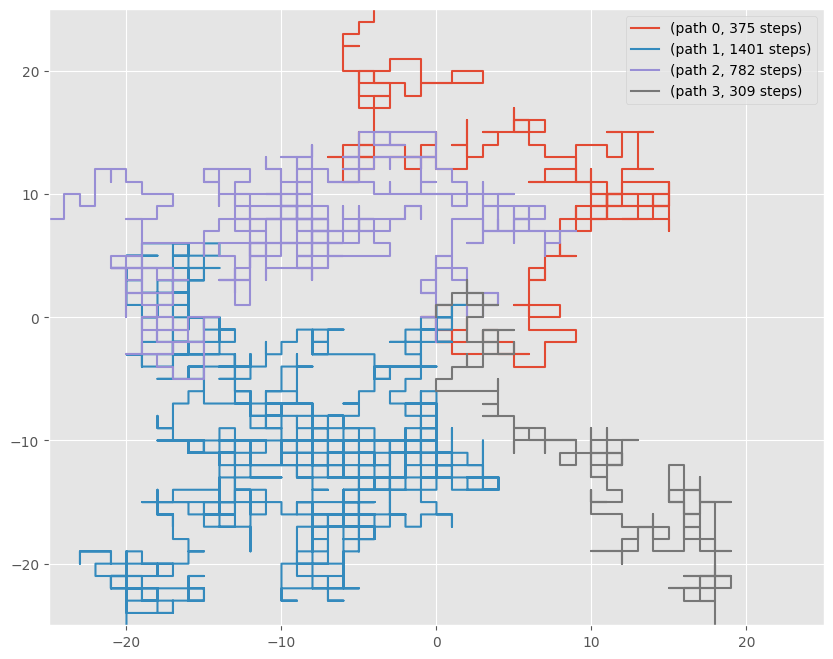

In [27]:
import random
import matplotlib.pyplot as plt
np = 4 # 這裡的 np 代表 path 數量，不是 numpy 別名
bdd = 25
# random walk：逐步更新座標
plt.figure(figsize = [10,8])
for k in range(np):
    i = 1
    x = [0]
    y = [0]
    while i > 0:  # 每條路徑走到越界才停止
        if (abs(x[i-1]) > bdd) | (abs(y[i-1]) > bdd):
            print(f'path {k} with steps = {i}')
            plt.plot(x,y,label = f'(path {k}, {i} steps)')
            break
        else:
            val = random.randint(1,4) # `random.randint(a, b)`：在閉區間 `[a, b]` 隨機取整數
            if val == 1:
                tx,ty = x[i-1] + 1,y[i-1]
            elif val == 2:
                tx,ty = x[i-1] - 1,y[i-1]
            elif val == 3:
                tx,ty = x[i-1],y[i-1] + 1
            else:
                tx,ty = x[i-1],y[i-1] - 1
            x.append(tx)
            y.append(ty)
            i += 1
plt.xlim([-bdd,bdd])
plt.ylim([-bdd,bdd])
plt.legend(loc = 'best')  # `plt.legend(loc='best')`：自動放在最適合的位置


***
## 中央極限定理（CLT）
***
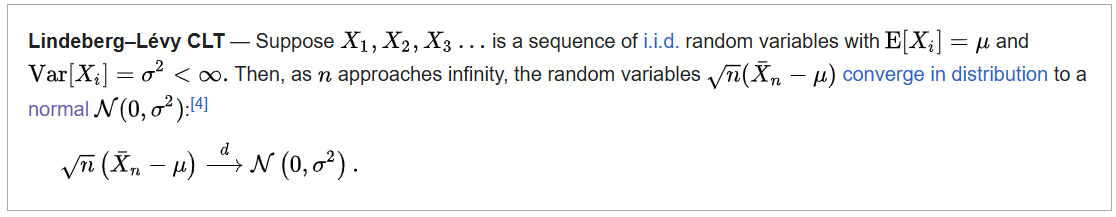  
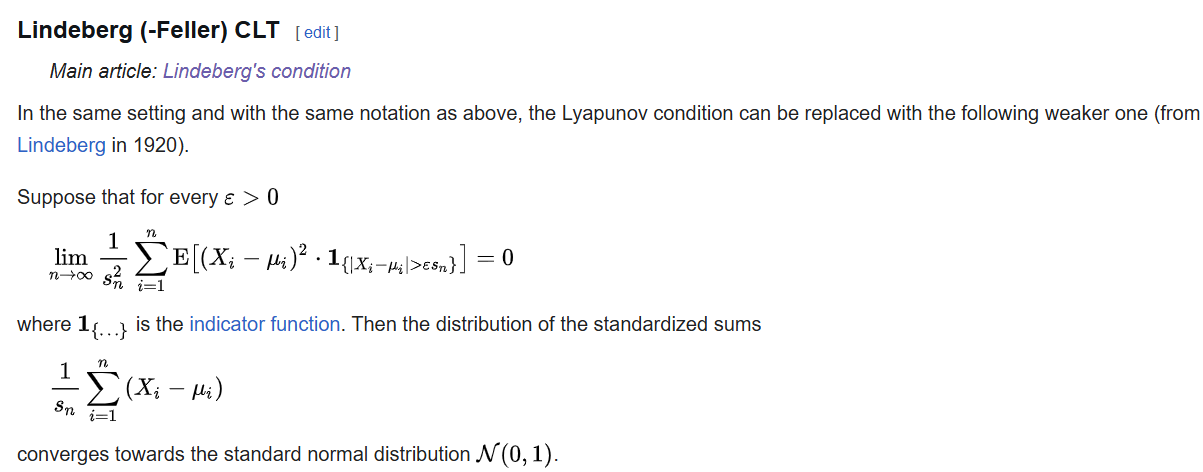


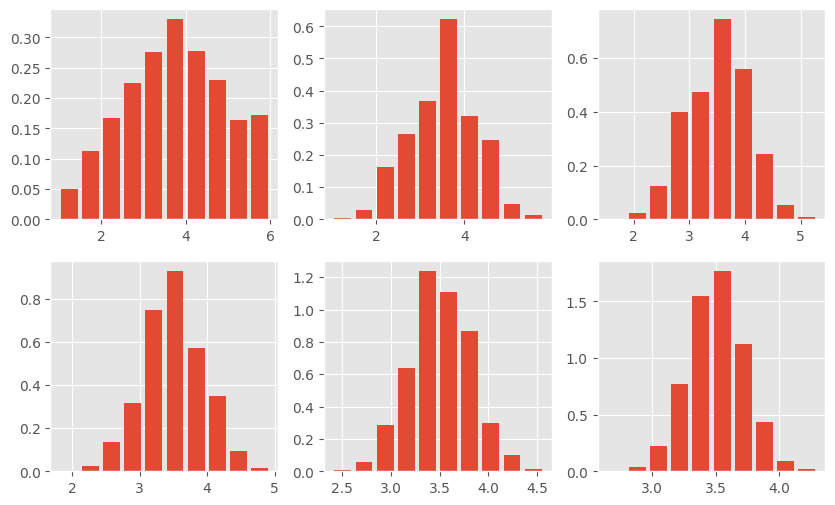

In [28]:
import scipy.stats as scs  # CLT 視覺化：n 增大時樣本平均分布更集中
import numpy as np
m = 10000
plt.figure(figsize = [10,6])
for k,n in enumerate([2,5,10,15,30,60]):
    plt.subplot(2,3,k+1)
    if n > 1:
        plt.hist(scs.randint(1,7).rvs((m,n)).mean(axis = 1),density = True,rwidth = 0.8)

***
## Numerical Integration
***


In [29]:
def Midpt(fn, area, n):
    a, b = area
    x = np.linspace(a, b, n + 1)  # 切出 n 個小區間需要 n+1 個端點
    h = (b - a) / n
    return np.sum(h * fn((x[:-1] + x[1:]) / 2)).item()  # 每段用中點高度乘寬度 h

def Trapezoid(fn, area, n):
    a, b = area
    x = np.linspace(a, b, n + 1)
    h = (b - a) / n
    return np.sum(h * (fn(x[:-1]) + fn(x[1:])) / 2).item()  # 每段用左右端點平均高度

def Simpson(f, area, n):
    a, b = area
    if n % 2 != 0:
        raise ValueError("n must be an even")  # Simpson rule 需要偶數個小區間
    x = np.linspace(a, b, n + 1)
    h = (b - a) / n
    y = f(x)
    return (h / 3) * (y[0] + 4 * np.sum(y[1::2]) + 2 * np.sum(y[2::2]) + y[-1])


In [30]:
import pandas as pd  # 彙整不同分割數下三種積分結果
f = lambda x:np.sin(x)
area = [0,np.pi]
seqN = [10,50,100,500] # 分割數
tval = 2
dr = []
for n in seqN:
    m1 = Midpt(f,area,n)
    m2 = Trapezoid(f,area,n)
    m3 = Simpson(f,area,n)
    dr.append([m1,m2,m3])
df = pd.DataFrame(dr,  # `pd.DataFrame(records, columns=..., index=...)`
                  columns = ['Midpoint','Trapezoid','Simpson'],
                  index = [f'n = {n}' for n in seqN])  # `[f'n = {n}' for n in seqN]`
display(df)


,Midpoint,Trapezoid,Simpson
n = 10,2.008248,1.983524,2.00011
n = 50,2.000329,1.999342,2.00000
n = 100,2.000082,1.999836,2.00000
n = 500,2.000003,1.999993,2.00000


***
## Monte Carlo Integration
***
$\displaystyle \frac{\sum_{i=1}^{n}g(X_i)}{n}\rightarrow E(g(X))=\int_{D(f)} g(x)f(x)dx$
## Example 1
$\displaystyle \int_{0}^{\pi}\sin(x)dx=\pi\cdot E(\sin(U)) \hbox{ where } U \sim U(0,\pi)$  

Hence we can estimate it by  

$\displaystyle \pi\cdot\frac{\sum_{i=1}^{n}\sin(U_i)}{n}\rightarrow \pi\cdot E(\sin(U))=\int_{0}^{\pi}\sin(x)dx$


In [31]:
# Monte Carlo 積分與高精度積分對照
import numpy as np
runs = 100000
samples = np.sin(np.random.uniform(0, np.pi, runs))
mc_val, mc_std = np.mean(samples), np.std(samples)  # `np.mean()` / `np.std()`：計算平均與標準差
# `scipy.integrate.quad()`：做高精度數值積分
import scipy as sc
val, tols = sc.integrate.quad(lambda x: np.sin(x), 0, np.pi)
display(f'MCMC est = {np.pi * mc_val:.3f} with std = {np.pi * mc_std:.3f}',
        f'Numerical integration = {val:.3f} with tolerance = {tols}')


'MCMC est = 1.999 with std = 0.966'

'Numerical integration = 2.000 with tolerance = 2.220446049250313e-14'

***
## Box-Muller transform
***
Suppose $U_1, U_2 \sim U(0,1)$ and are indepedent  
$Z_0 = R \cos(\Theta)=\sqrt{-2\ln U_1} \cos(2\pi U_2)$  
$Z_1 = R \sin(\Theta)=\sqrt{-2\ln U_1} \sin(2\pi U_2)$  
$R^2=-2\ln U_1$  
$\Theta = 2\pi U_2$


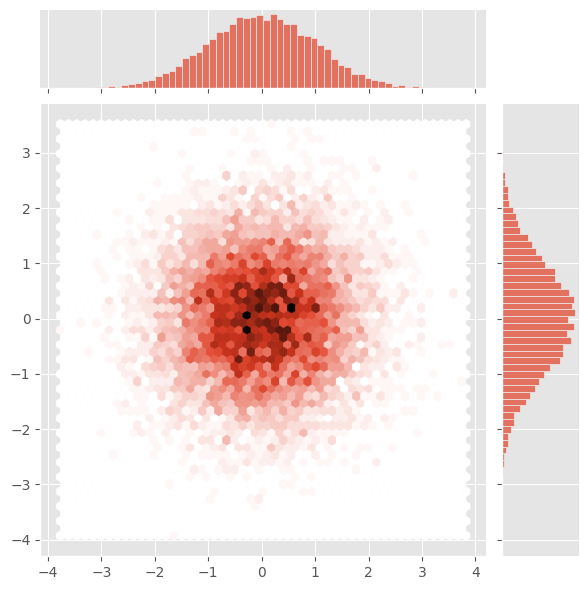

In [32]:
import numpy as np  # Box-Muller 把均勻亂數轉成二維常態樣本
import seaborn as sns
U1 = np.random.uniform(size = 10000)
U2 = np.random.uniform(size = 10000)
R = np.sqrt(-2 * np.log(U1))
theta = 2 * np.pi * U2
X = R * np.cos(theta)
Y = R * np.sin(theta)
sns.jointplot(x = X,y = Y,kind = 'hex')


***
## Cryptography
***

#### 當 `a = 1` 時，Affine Cipher 退化為 Shift Cipher


In [33]:
[ord(k) for k in list('abcdefghijklmnopqrstuvwxyz')]  # `ord(c)` + list comprehension


[97,
 98,
 99,
 100,
 101,
 102,
 103,
 104,
 105,
 106,
 107,
 108,
 109,
 110,
 111,
 112,
 113,
 114,
 115,
 116,
 117,
 118,
 119,
 120,
 121,
 122]

In [34]:
chr(97)  # `chr(n)`


'a'

In [35]:
import math  # Affine cipher：線性位移加密，先確保 key 可逆
def Cipher_A(ptext:str ,a: int,b: int) -> str:  # type hint：標註參數與回傳型別
    if math.gcd(a,26) != 1:
        raise ValueError("The value 'a' must be coprime to 26.")
    res = ""
    for char in ptext:
        if char.isalpha():  # `str.isalpha()`：判斷是否為字母
            start = ord('A') if char.isupper() else ord('a')  # `str.isupper()` 搭配 `ord()` 判斷與轉碼
            x = ord(char) - start
            res += chr(((a*x + b) % 26) + start)  # `(a*x + b) % 26`
        else:
            res += char
    return res  # `return`：回傳結果並結束函式


In [36]:
# a=1 時退化為 Caesar cipher（位移 7）
Cipher_A("I MUST NOT FEAR. FEAR IS THE MIND-KILLER",1,7)


'P TBZA UVA MLHY. MLHY PZ AOL TPUK-RPSSLY'

In [37]:
puzzle = 'P TBZA UVA MLHY. MLHY PZ AOL TPUN-RPSSLY'
# 暴力回推多個位移量，人工挑可讀結果
for k in range(1,8):
    print(f'Shift back {k}: {Cipher_A(puzzle,1,-k)}')


Shift back 1: O SAYZ TUZ LKGX. LKGX OY ZNK SOTM-QORRKX
Shift back 2: N RZXY STY KJFW. KJFW NX YMJ RNSL-PNQQJW
Shift back 3: M QYWX RSX JIEV. JIEV MW XLI QMRK-OMPPIV
Shift back 4: L PXVW QRW IHDU. IHDU LV WKH PLQJ-NLOOHU
Shift back 5: K OWUV PQV HGCT. HGCT KU VJG OKPI-MKNNGT
Shift back 6: J NVTU OPU GFBS. GFBS JT UIF NJOH-LJMMFS
Shift back 7: I MUST NOT FEAR. FEAR IS THE MING-KILLER


In [38]:
def Cipher_S(ptext: str,mapping: str) -> str:  # Substitution cipher：先建映射表再逐字替換
    alphabet = "abcdefghijklmnopqrstuvwxyz"
    res = ""
    rule = {alphabet[k]:mapping[k] for k in range(len(alphabet))}  #dict comprehension
    for char in ptext.lower():  # `str.lower()`：轉成小寫
        if char in rule:
            res += rule[char]
        else:
            res += char
    return res  # `return`：回傳結果並結束函式


#### Substitution Cipher 的特例：Affine Cipher


In [39]:
mapping = 'insxchmrwbglqvafkpuzejotyd'
plaintext = 'chicken winner chicken dinner'
display(Cipher_S(plaintext,mapping),
        Cipher_A(plaintext,5,8))


'srwsgcv owvvcp srwsgcv xwvvcp'

'srwsgcv owvvcp srwsgcv xwvvcp'

In [40]:
def Cipher_V(ptext: str,keyword: str) -> str:  # Vigenere：依 key 循環提供每個字元位移
    result = []
    key = keyword.lower()
    key_index = 0
    for char in ptext:
        if char.isalpha():
            start = ord('A') if char.isupper() else ord('a')
            # `key_index % len(key)` cyclic indexing
            shift = ord(key[key_index % len(key)]) - ord('a')
            result.append(chr((ord(char) - start + shift) % 26 + start))  # `list.append()`：在尾端加入元素
            key_index += 1
        else:
            result.append(char)

    return "".join(result)  # `"".join(list)`


In [41]:
Cipher_V("THINK ABOUT IT","VINTAGE")  # `Cipher_V()`：Vigenere cipher 函式


'OPVGK GFJCG BT'

In [42]:
def get_Mk(keystr):  # 把 key 字串轉成 Hill cipher 方陣金鑰
    n = int(np.sqrt(len(keystr)))  # `int(np.sqrt(len(...)))`
    return np.array([ord(k) % 65 for k in 'GYBNQKURP']).reshape(n,n)  # `np.array([...]).reshape(n,n)`


In [43]:
def Cipher_H(ptext,Mk,mode = 'encrypt'):  # Hill cipher：分塊做模 26 矩陣運算；解密需反矩陣
    n = Mk.shape[0]  # `Mk.shape[0]`
    ptext = ptext.upper().replace(" ", "")  # 先轉大寫並移除空白，統一輸入格式
    # 長度不足時補 X，避免末塊維度不完整
    while len(ptext) % n != 0:  # `while`：條件為真就持續迴圈
        ptext += 'X'
    # Convert text to numbers and reshape into blocks of size n
    blocks = np.array([ord(c) - ord('A') for c in ptext]).reshape(-1, n)  # 把字元轉數字並重排成每列 n 個
    if mode == 'encrypt':
        apply_matrix = Mk
    else:
        # 解密模式需先求模 26 反矩陣
        det = int(np.round(np.linalg.det(Mk))) % 26  # 先算 det 並取 mod 26
        # Find modular inverse of the determinant
        inv_det = -1
        for i in range(1, 26):
            if (det * i) % 26 == 1:
                inv_det = i
                break
        if inv_det == -1:
            raise ValueError("Matrix is not invertible modulo 26.")
        adj = np.round(np.linalg.inv(Mk) * np.linalg.det(Mk)).astype(int)  # 用 adjugate 形式組回整數反矩陣
        apply_matrix = (inv_det * adj) % 26
    result_nums = (blocks @ apply_matrix.T) % 26  # 每塊向量乘上矩陣後再取 mod 26
    # 把數值結果轉回字元並串接
    return "".join(chr(int(num) + ord('A')) for num in result_nums.flatten())  # `return`：回傳結果並結束函式


In [44]:
keyMat = np.array([[3, 3],  # 加密後立刻解密，驗證 round-trip
                   [2, 5]])
cipher = Cipher_H("HELP",keyMat,mode = 'encrypt')  # `Cipher_H()`：Hill cipher 加密
plain  = Cipher_H(cipher,keyMat,mode = 'decrypt')  # `Cipher_H()`：Hill cipher 解密
print(f"Key Matrix:\n {keyMat}")  # `f"Key Matrix:\n {keyMat}"
print(f"Ciphertext: {cipher}")
print(f"Decrypted:  {plain}")


Key Matrix:
 [[3 3]
 [2 5]]
Ciphertext: HIAT
Decrypted:  HELP


In [45]:
def get_Mk(keystr):  # 此格會覆寫前面同名 get_Mk
    n = int(np.sqrt(len(keystr)))
    return np.array([ord(k) % 65 for k in 'GYBNQKURP']).reshape(n,n)  # `return`：回傳結果並結束函式


In [46]:
# 使用經典 3x3 key matrix 示範 Hill 加解密
keyMat = get_Mk('GYBNQKURP')
cipher = Cipher_H("ACT",keyMat,mode = 'encrypt')  # 用該矩陣加密 ACT
plain  = Cipher_H(cipher,keyMat,mode = 'decrypt')  # 再解密驗證可回到原文
print(f"Key Matrix:\n {keyMat}")
print(f"Ciphertext: {cipher}")
print(f"Decrypted:  {plain}")


Key Matrix:
 [[ 6 24  1]
 [13 16 10]
 [20 17 15]]
Ciphertext: POH
Decrypted:  ACT
